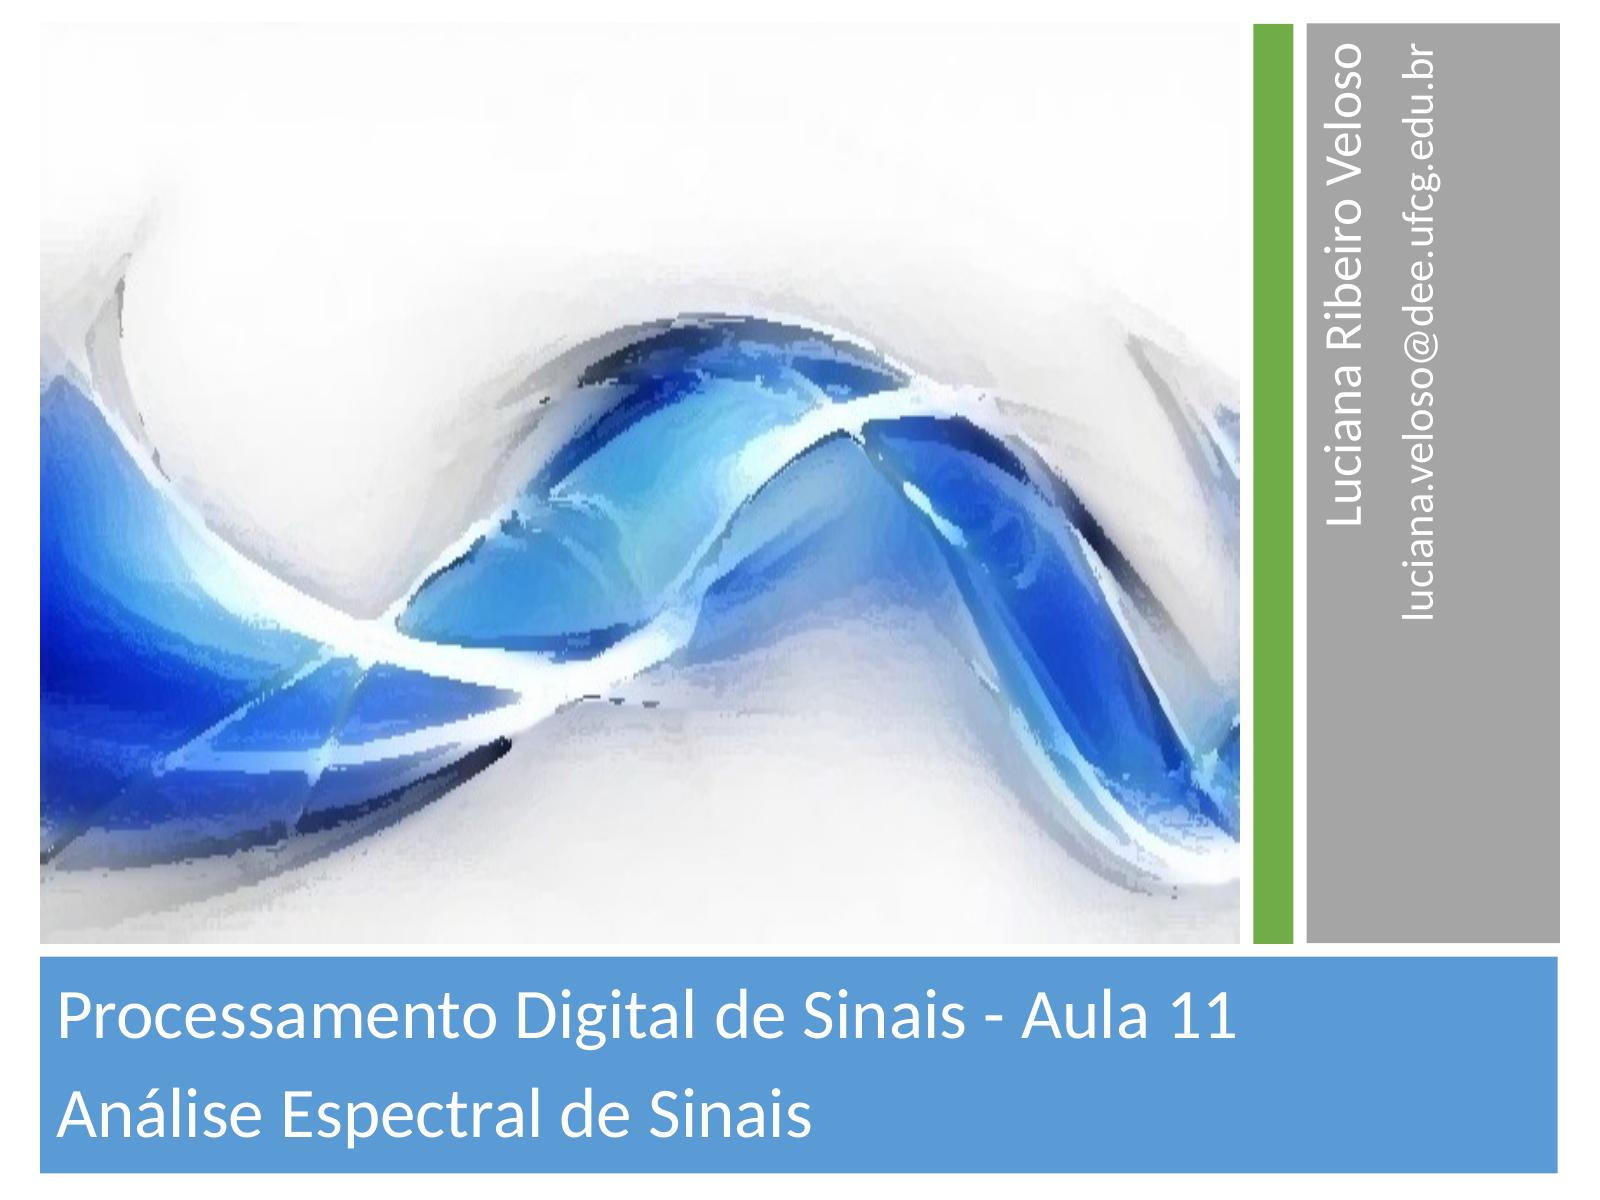

# Análise Espectral de Sinais — Laboratório Interativo

**Processamento Digital de Sinais — Aula 11 (caderno interativo)**
Prof.ª Luciana Ribeiro Veloso · DEE/UFCG · `luciana.veloso@dee.ufcg.edu.br`

---

## Objetivos

Ao final deste caderno você será capaz de:

1. Estimar o **espectro** de um trecho de sinal usando a **DFT** e entender por que a DFT *amostra* a DTFT.
2. Reconhecer a **cadeia de processamento** da análise de Fourier em tempo discreto (filtro *antialiasing* → conversão C/D → janelamento → DFT).
3. Analisar, por DFT, sinais senoidais e identificar os três fenômenos que distorcem a leitura do espectro:
   * **(a)** efeito do **janelamento** (vazamento espectral / *spectral leakage*);
   * **(b)** **propriedades das janelas** (compromisso largura do lobo principal × nível dos lobos laterais);
   * **(c)** efeito da **amostragem espectral** (*picket-fence* / *scalloping*) e o papel do *zero-padding*.

<div style="background:#E8F0FE;border-left:6px solid #1E4E8C;padding:10px 14px;border-radius:4px;margin-top:8px">
<b>📌 Como usar:</b> execute as células de cima para baixo. As células de código abrem <i>sliders</i> e menus — mexa nos controles e observe o espectro mudar em tempo real. Requer <code>numpy</code>, <code>matplotlib</code>, <code>scipy</code> e <code>ipywidgets</code>.
</div>


### Importação dos pacotes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display, Audio, HTML

### Configurações visuais e funções auxiliares

In [2]:
# ----------------------------------------------------------------------
# Paleta de cores e funções auxiliares (estilo padrão das aulas de PDS)
# ----------------------------------------------------------------------
PALETA = {
    'azul':     '#1E4E8C',   # azul escuro (cabeçalhos)
    'azul_c':   '#4A90E2',
    'verde':    '#2E8B57',
    'laranja':  '#E8743B',
    'vermelho': '#C0392B',
    'roxo':     '#7D3C98',
    'cinza':    '#7F8C8D',
}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.30, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 10,
})

# Janelas disponíveis (nome amigável -> nome no scipy)
JANELAS = {'Retangular': 'boxcar', 'Bartlett': 'bartlett', 'Hann': 'hann',
           'Hamming': 'hamming', 'Blackman': 'blackman'}

def stem_plot(ax, n, x, cor=None, label=None, markerfmt='o'):
    """Stem padronizado (haste fina + marcador pequeno)."""
    cor = cor or PALETA['azul']
    ml, sl, bl = ax.stem(n, x, linefmt='-', markerfmt=markerfmt, basefmt=' ')
    plt.setp(sl, color=cor, linewidth=1.3)
    plt.setp(ml, color=cor, markersize=4, label=label)
    return ml

def dtft(x, n0=0, num=4096, faixa=(-np.pi, np.pi)):
    """DTFT de x[n] avaliada num pontos em [faixa]. n0 = índice da 1a amostra."""
    w = np.linspace(faixa[0], faixa[1], num)
    n = np.arange(len(x)) + n0
    fase = np.exp(-1j * np.outer(n, w))
    # errstate evita RuntimeWarnings espúrios do BLAS Accelerate (Macs Apple Silicon)
    with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
        X = x @ fase
    return w, X

def sinal_2tons(M, w0, w1, A0=1.0, A1=0.75):
    """x[n] = A0 cos(w0 n) + A1 cos(w1 n), com n = 0..M (comprimento M+1)."""
    n = np.arange(0, M + 1)
    return n, A0 * np.cos(w0 * n) + A1 * np.cos(w1 * n)

def nivel_lobo_lateral(nome, L, Nfft=8192):
    """Retorna o nível (dB) do maior lobo lateral da janela de L pontos."""
    wnd = signal.get_window(JANELAS[nome], L)
    W = np.abs(np.fft.rfft(wnd, Nfft))
    Wdb = 20 * np.log10(W / W.max() + 1e-12)
    d = np.diff(Wdb)
    nulos = np.where((d[:-1] < 0) & (d[1:] > 0))[0]
    return Wdb[nulos[0] + 1:].max() if len(nulos) else np.nan

def sliders_L_N(L0, N0, Lmax, Nmax, Lstep=1, Nstep=8):
    """Cria os sliders L (janela) e N (DFT) com a restrição N >= L garantida na interface."""
    L = widgets.IntSlider(value=L0, min=8,  max=Lmax, step=Lstep, description='L (janela)')
    N = widgets.IntSlider(value=N0, min=L0, max=Nmax, step=Nstep, description='N (DFT)')
    def _sync(_):
        N.min = L.value              # N nunca pode ser menor que L
        if N.value < L.value:
            N.value = L.value
    L.observe(_sync, names='value')
    return L, N

print('Ambiente pronto. Paleta e funções auxiliares carregadas.')

Ambiente pronto. Paleta e funções auxiliares carregadas.


# 1. Por que análise espectral?

Em muitos sinais a informação relevante está no **domínio da frequência**, não na forma de onda. Em **áudio** e **voz**, por exemplo, o que importa é o **espectro** — quais componentes senoidais existem e com que amplitude/fase — e não o traçado instantâneo de $x(t)$.

A ideia central da aula:

> Usamos a **DFT** para calcular o espectro de um **trecho de duração finita** de um sinal e, assim, *visualizar* o seu conteúdo de frequência.

Mas a DFT exige um sinal de **comprimento finito**. Sinais reais (uma música, uma fala) são longos demais, então recortamos um pedaço — e é justamente esse recorte que introduz os artefatos que estudaremos.


# 2. Análise de Fourier de sinais usando a TFD

A cadeia de processamento para a análise de Fourier em tempo discreto de um sinal de tempo contínuo $s_c(t)$ é (Oppenheim & Schafer, *Processamento em Tempo Discreto de Sinais*, Pearson, 2013):


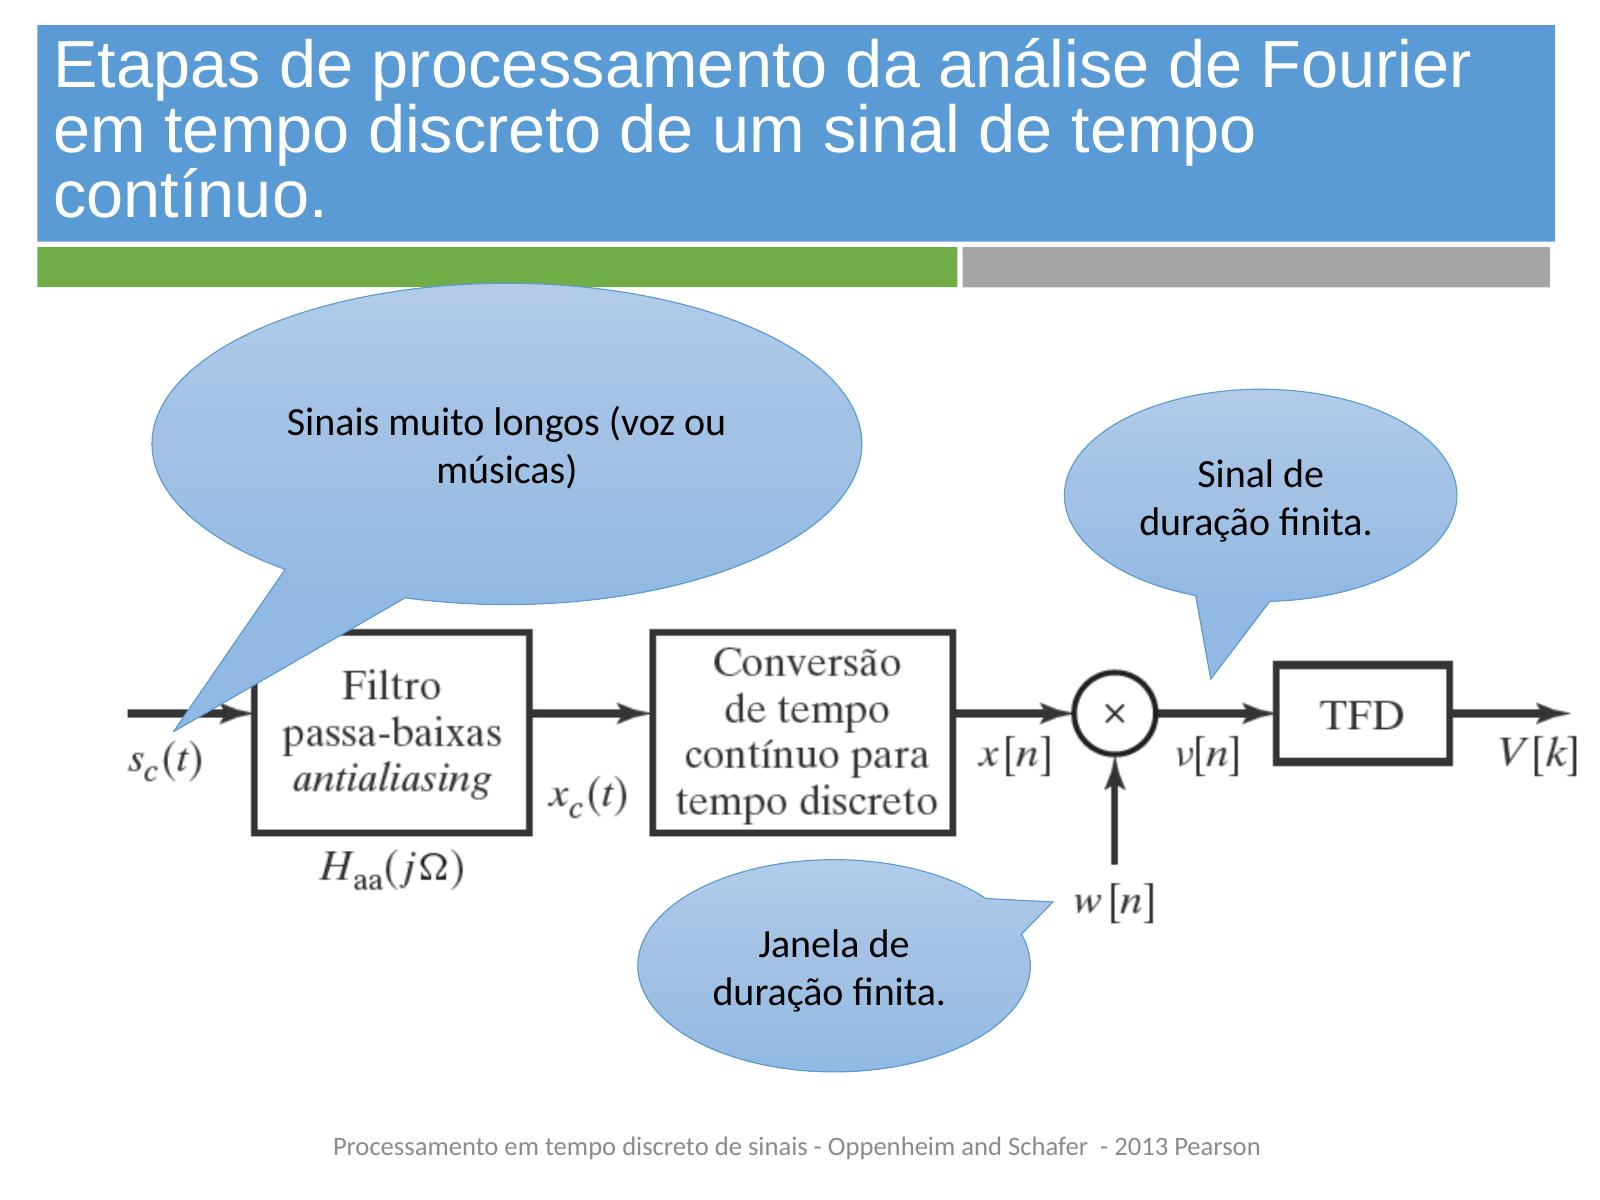

**Etapas:**

1. **Filtro passa-baixas *antialiasing*** $H_{aa}(j\Omega)$ — limita a banda antes da amostragem.
2. **Conversão C/D** — gera a sequência $x[n]$ de duração ainda muito longa.
3. **Janelamento** — multiplicamos por uma janela $w[n]$ de **duração finita**, obtendo o sinal de duração finita

$$ v[n] = x[n]\,w[n] $$

4. **DFT** — calcula $V[k]$, as amostras do espectro.

No domínio da frequência, a multiplicação no tempo vira **convolução periódica**:

$$ V(e^{j\omega}) = \frac{1}{2\pi}\, X(e^{j\omega}) \,\circledast\, W(e^{j\omega}) $$

Ou seja: o espectro verdadeiro $X(e^{j\omega})$ é **borrado** pela transformada da janela $W(e^{j\omega})$. Esse é o ponto de partida de tudo o que vem a seguir.

Para a **janela retangular** de comprimento $M+1$:

$$ W(e^{j\omega}) = \sum_{n=0}^{M} e^{-j\omega n} = e^{-j\omega M/2}\,\frac{\sin[\omega(M+1)/2]}{\sin(\omega/2)} $$

um núcleo de Dirichlet com **lobo principal** de largura $\approx 4\pi/L$ e **lobos laterais** decaindo lentamente (aqui $M = L-1$, isto é, a janela tem $L = M+1$ pontos).


# 3. Análise por DFT de sinais senoidais

Para interpretar corretamente o espectro de senoides via DFT precisamos entender **três efeitos**:

| | Efeito | Causa | Consequência |
|---|---|---|---|
| (a) | **Janelamento** | recorte de duração finita | impulsos *espalhados/alargados* (vazamento) |
| (b) | **Escolha da janela** | formato de $w[n]$ | compromisso resolução × faixa dinâmica |
| (c) | **Amostragem espectral** | DFT amostra a DTFT | *picket-fence* / *scalloping* |

Vamos estudar cada efeito com **sinais senoidais simples** — começando por um único cosseno (3.a) e depois com duas componentes próximas.

## 3.a) Efeito do janelamento (vazamento espectral)

**Começamos pelo caso mais simples: um único cosseno.**

Comece pelo sinal mais simples possível — um único cosseno:

$$ x[n] = \cos(\omega_0 n) $$

**O que esperaríamos ver.** A representação de Fourier de um cosseno *eterno* são **dois impulsos** (deltas de Dirac), em $+\omega_0$ e $-\omega_0$:

$$ X(e^{j\omega}) = \pi\,\delta(\omega-\omega_0) + \pi\,\delta(\omega+\omega_0) $$

**O que o janelamento faz.** Na prática só dispomos de um **trecho finito** — multiplicamos o cosseno por uma **janela** $w[n]$ de comprimento $L$:

$$ v[n] = x[n]\,w[n] $$

No domínio da frequência, a multiplicação no tempo vira **convolução periódica**:

$$ V(e^{j\omega}) = \frac{1}{2\pi}\, X(e^{j\omega}) \circledast W(e^{j\omega}) $$

Como $X(e^{j\omega})$ é formado por **impulsos**, a convolução apenas **copia** $W(e^{j\omega})$ centrada em $\pm\omega_0$. Resultado: cada impulso é substituído por uma cópia de $W(e^{j\omega})$ — para a janela **retangular**, uma **sinc** (lobo principal + lobos laterais). Em vez de **dois impulsos**, vemos **dois lobos espalhados**: esse alargamento é o **efeito do janelamento**.

A simulação a seguir mostra esse efeito **no tempo** (o cosseno sendo moldado pela janela) e **na frequência**, via **TFTD** — a transformada de tempo discreto $V(e^{j\omega})$, que é uma curva **contínua** em $\omega$.

<div style="background:#E8F0FE;border-left:6px solid #1E4E8C;padding:8px 14px;border-radius:4px">
Aqui ainda <b>não</b> há DFT: olhamos a TFTD inteira. <i>Como</i> a DFT depois amostra essa curva em pontos discretos — e por que o pico pode não cair onde imaginávamos — é o assunto do <b>item (c)</b>.
</div>


In [3]:
def lab_janelamento_tftd(L=48, f0=0.10, janela='Retangular'):
    Ntot = 128                                   # trecho exibido do sinal "longo" x[n]
    L = min(int(L), Ntot)
    n = np.arange(Ntot)

    x = np.cos(2*np.pi*f0*n)                      # sinal: cosseno em TODO o eixo n
    w = np.zeros(Ntot)
    w[:L] = signal.get_window(JANELAS[janela], L) # janela: L pontos, o resto zeros
    v = x*w                                       # v[n] = x[n]·w[n]

    # TFTD (curva contínua) do sinal janelado v[n]
    ww, V = dtft(v, num=4096, faixa=(-np.pi, np.pi))
    w0 = 2*np.pi*f0

    fig = plt.figure(figsize=(13, 6))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.15, 1.25], hspace=0.55, wspace=0.22)
    ax_x = fig.add_subplot(gs[0, 0])
    ax_w = fig.add_subplot(gs[1, 0], sharex=ax_x)
    ax_v = fig.add_subplot(gs[2, 0], sharex=ax_x)
    ax_f = fig.add_subplot(gs[:, 1])

    # --- tempo: x[n], w[n], v[n] (mesmo eixo n) ---
    ax_x.plot(n, x, color=PALETA['cinza'], lw=1.1, marker='.', ms=3)
    ax_x.set_title(r'$x[n] = \cos(2\pi f_0 n)$  (sinal longo)', fontsize=10)
    ax_x.set_ylim(-1.2, 1.2)

    ax_w.fill_between(n, 0, w, step='mid', color=PALETA['verde'], alpha=0.35)
    ax_w.plot(n, w, color=PALETA['verde'], lw=1.3, drawstyle='steps-mid')
    ax_w.set_title(f'$w[n]$  (janela {janela}: L={L} pontos, resto zeros)', fontsize=10)
    ax_w.set_ylim(-0.15, 1.2)

    ax_v.plot(n, v, color=PALETA['azul'], lw=1.1, marker='.', ms=3)
    ax_v.axvspan(0, L-1, color=PALETA['verde'], alpha=0.08)
    ax_v.set_title(r'$v[n] = x[n]\,w[n]$  (trecho recortado)', fontsize=10)
    ax_v.set_ylim(-1.2, 1.2); ax_v.set_xlabel('n')

    # --- frequência: TFTD de v[n] (impulso -> sinc) ---
    ax_f.plot(ww/np.pi, np.abs(V), color=PALETA['azul'], lw=1.5, label='|V(e^{jω})| (TFTD)')
    for s in (+1, -1):
        ax_f.axvline(s*w0/np.pi, color=PALETA['vermelho'], ls=':', lw=1.4)
    ax_f.text(w0/np.pi, np.abs(V).max()*0.96, 'impulso\nideal', color=PALETA['vermelho'],
              fontsize=8, ha='center', va='top')
    ax_f.set_xlim(-1, 1); ax_f.set_xlabel('ω/π'); ax_f.set_ylabel('Magnitude')
    ax_f.set_title('TFTD de v[n] — cada impulso vira uma sinc', fontsize=10)
    ax_f.legend(fontsize=8)
    plt.show()

widgets.interact(
    lab_janelamento_tftd,
    L=widgets.IntSlider(value=48, min=8, max=128, step=4, description='L (janela)'),
    f0=widgets.FloatSlider(value=0.10, min=0.02, max=0.45, step=0.01, readout_format='.2f',
                           description='f₀ (ciclos/amostra)'),
    janela=widgets.Dropdown(options=list(JANELAS), value='Retangular', description='Janela'),
);

interactive(children=(IntSlider(value=48, description='L (janela)', max=128, min=8, step=4), FloatSlider(value…

<div style="background:#FFF4E5;border-left:6px solid #E8743B;padding:10px 14px;border-radius:4px">
<b>⚠️ O que observar:</b>
<ul style="margin:6px 0">
<li>Com a janela <b>retangular</b>, cada impulso vira uma <b>sinc</b>: um lobo principal (largura ≈ $4\pi/L$) cercado de <b>lobos laterais</b> — o <i>vazamento</i>.</li>
<li>Aumente <b>L</b>: o lobo principal <b>estreita</b> e o espectro se aproxima do impulso ideal (linhas pontilhadas).</li>
<li>Troque a <b>janela</b> (Hann, Hamming, Blackman): os lobos laterais <b>caem</b> (menos vazamento), mas o lobo principal <b>alarga</b>. Esse compromisso é o tema do item <b>(b)</b>.</li>
<li>Tudo isto é a <b>TFTD</b>, uma curva contínua. A amostragem dela pela DFT vem no item <b>(c)</b>.</li>
</ul>
</div>


### Agora com dois tons: vazamento e resolução entre componentes próximas

Passamos a um sinal com **duas** componentes senoidais (o sinal-modelo de Oppenheim):

$$ x[n] = \cos(\omega_0 n) + 0{,}75\cos(\omega_1 n) $$

O espectro *ideal* são **quatro impulsos** — em $\pm\omega_0$ e $\pm\omega_1$. Ao janelar, cada impulso vira uma cópia de $W(e^{j\omega})$ (uma *sinc*, no caso retangular), e os lobos das duas componentes podem **se sobrepor**.

**O que a simulação faz:** monta o sinal janelado $v[n] = x[n]\,w[n]$ — com janela de comprimento $L$ escolhida no menu —, calcula a **TFTD** $V(e^{j\omega})$ e mostra o sinal janelado (acima) e o módulo do espectro (abaixo). As frequências entram na forma $\omega = 2\pi/k$: ajuste os divisores $k_0$ e $k_1$ (as linhas tracejadas marcam $\omega_0$ e $\omega_1$).

**Reproduza os três casos clássicos** (janela retangular):

* **Caso 1 — bem separadas:** $k_0 = 6,\ k_1 = 3$  ($\omega_0 = 2\pi/6,\ \omega_1 = 2\pi/3$) → dois picos nítidos.
* **Caso 2 — próximas:** $k_0 = 14,\ k_1 = 7{,}5$  ($\omega_0 = 2\pi/14,\ \omega_1 = 4\pi/15$) → ainda resolvidas.
* **Caso 3 — muito próximas:** $k_0 = 14,\ k_1 = 12$  ($\omega_0 = 2\pi/14,\ \omega_1 = 2\pi/12$) → os lobos se fundem; **não** se resolvem.


In [4]:
def lab_janelamento(L=64, div0=6.0, div1=3.0, janela='Retangular'):
    w0, w1 = 2*np.pi/div0, 2*np.pi/div1
    n = np.arange(L)
    x = np.cos(w0*n) + 0.75*np.cos(w1*n)
    w = signal.get_window(JANELAS[janela], L)
    v = x*w
    ww, V = dtft(v, num=8192)

    fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 6.4))
    stem_plot(a0, n, v, PALETA['azul'])
    a0.set_title(f'v[n] = x[n]·w[n]   |   janela {janela},  L = {L}')
    a0.set_xlabel('n'); a0.set_ylabel('v[n]')

    a1.plot(ww/np.pi, np.abs(V), color=PALETA['azul'], lw=1.4)
    for f, c in [(w0, 'verde'), (w1, 'laranja')]:
        a1.axvline(f/np.pi, color=PALETA[c], ls='--', lw=1.2)
    a1.text(w0/np.pi, a1.get_ylim()[1]*0.92, r'$\omega_0$', color=PALETA['verde'], ha='center')
    a1.text(w1/np.pi, a1.get_ylim()[1]*0.92, r'$\omega_1$', color=PALETA['laranja'], ha='center')
    a1.set_xlim(0, 1); a1.set_xlabel('ω/π'); a1.set_ylabel('|V(e^{jω})|')
    a1.set_title('Espectro (TFTD do sinal janelado) — vazamento e fusão dos picos')
    plt.tight_layout(); plt.show()

widgets.interact(
    lab_janelamento,
    L=widgets.IntSlider(value=64, min=8, max=256, step=4, description='L (janela)'),
    div0=widgets.FloatSlider(value=6.0, min=3.0, max=20.0, step=0.5, description='k₀ (ω₀=2π/k₀)'),
    div1=widgets.FloatSlider(value=3.0, min=3.0, max=20.0, step=0.5, description='k₁ (ω₁=2π/k₁)'),
    janela=widgets.Dropdown(options=list(JANELAS), value='Retangular', description='Janela'),
);

interactive(children=(IntSlider(value=64, description='L (janela)', max=256, min=8, step=4), FloatSlider(value…

<div style="background:#FFF4E5;border-left:6px solid #E8743B;padding:10px 14px;border-radius:4px">
<b>⚠️ O que observar:</b>
<ul style="margin:6px 0">
<li>Aumente <b>L</b>: o lobo principal estreita (<i>melhora a resolução</i>) e os picos voltam a se separar — mesmo no caso 3.</li>
<li>Aproxime <b>k₀</b> e <b>k₁</b>: com poucos pontos os dois picos se fundem num só (limite de resolução $\approx 4\pi/L$ para a retangular).</li>
<li>Troque a <b>janela</b> para Hann/Blackman: o vazamento (lobos laterais) cai, mas o lobo principal alarga.</li>
</ul>
</div>


## 3.b) Propriedades das janelas

Cada janela representa um **compromisso** entre dois parâmetros do espectro de $W(e^{j\omega})$:

* **Largura do lobo principal** → controla a **resolução** (capacidade de separar frequências próximas);
* **Nível do maior lobo lateral** → controla a **faixa dinâmica** (capacidade de enxergar uma componente fraca perto de uma forte).

**Valores de referência** (janela de $L$ pontos — Oppenheim & Schafer; Harris, 1978):

| Janela | Largura do lobo principal | 1º lobo lateral | Comentário |
|---|---|---|---|
| **Retangular** | $4\pi/L$ | $-13$ dB | pico estreito 🙂, caudas altas ☹ |
| **Bartlett** | $8\pi/L$ | $-25$ dB | triangular |
| **Hann (Hanning)** | $8\pi/L$ | $-31$ dB | bom geral |
| **Hamming** | $8\pi/L$ | $-41$ dB | **compromisso** clássico |
| **Blackman** | $12\pi/L$ | $-57$ dB | lobo largo ☹, caudas baixíssimas 🙂 |

A célula abaixo desenha as janelas no tempo e suas respostas em **dB** (compare com o slide de comparação da aula).


In [5]:
def comparar_janelas(L=50):
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.6))
    cores = {'Retangular': PALETA['azul'], 'Bartlett': PALETA['cinza'],
             'Hann': PALETA['verde'], 'Hamming': PALETA['vermelho'],
             'Blackman': PALETA['azul_c']}
    n = np.arange(L)
    Nfft = 8192
    wax = np.fft.rfftfreq(Nfft) * 2 * np.pi
    for nome, c in cores.items():
        wnd = signal.get_window(JANELAS[nome], L)
        a0.plot(n, wnd, color=c, lw=1.7, label=nome)
        W = np.abs(np.fft.rfft(wnd, Nfft))
        Wdb = 20*np.log10(W/W.max() + 1e-12)
        a1.plot(wax/np.pi, Wdb, color=c, lw=1.3, label=f'{nome} ({nivel_lobo_lateral(nome, L):.0f} dB)')
    a0.set_title(f'Janelas no domínio do tempo (L={L})')
    a0.set_xlabel('n'); a0.set_ylabel('w[n]'); a0.legend(fontsize=8)
    a1.set_title('Resposta em frequência |W(e^{jω})| em dB')
    a1.set_xlim(0, 1); a1.set_ylim(-100, 5)
    a1.set_xlabel('ω/π'); a1.set_ylabel('dB'); a1.legend(fontsize=8)
    plt.tight_layout(); plt.show()

widgets.interact(comparar_janelas,
                 L=widgets.IntSlider(value=50, min=8, max=200, step=2, description='L (janela)'));

interactive(children=(IntSlider(value=50, description='L (janela)', max=200, min=8, step=2), Output()), _dom_c…

### Janela de Kaiser

A janela de **Kaiser** é ajustável por um parâmetro $\beta$, permitindo *escolher* o compromisso:

$$ w[n] = \frac{I_0\!\left(\beta\sqrt{1-\left(\tfrac{n-(L-1)/2}{(L-1)/2}\right)^2}\right)}{I_0(\beta)}, \qquad 0 \le n \le L-1 $$

onde $I_0(\cdot)$ é a função de Bessel modificada de ordem zero. **$\beta$ pequeno** → próxima da retangular (lobo estreito, caudas altas); **$\beta$ grande** → próxima da Blackman (lobo largo, caudas baixas).


In [6]:
def lab_kaiser(L=50, beta=6.0):
    n = np.arange(L)
    wnd = signal.windows.kaiser(L, beta=beta)
    Nfft = 8192
    W = np.abs(np.fft.rfft(wnd, Nfft))
    Wdb = 20*np.log10(W/W.max() + 1e-12)
    wax = np.fft.rfftfreq(Nfft) * 2*np.pi

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
    a0.plot(n, wnd, color=PALETA['roxo'], lw=1.9)
    a0.set_title(f'Kaiser — β = {beta:.1f},  L = {L}')
    a0.set_xlabel('n'); a0.set_ylabel('w[n]')
    a1.plot(wax/np.pi, Wdb, color=PALETA['roxo'], lw=1.3)
    a1.set_xlim(0, 1); a1.set_ylim(-120, 5)
    a1.set_title('|W(e^{jω})| (dB)'); a1.set_xlabel('ω/π'); a1.set_ylabel('dB')
    plt.tight_layout(); plt.show()

widgets.interact(lab_kaiser,
                 L=widgets.IntSlider(value=50, min=8, max=200, step=2, description='L (janela)'),
                 beta=widgets.FloatSlider(value=6.0, min=0.0, max=14.0, step=0.5, description='β'));

interactive(children=(IntSlider(value=50, description='L (janela)', max=200, min=8, step=2), FloatSlider(value…

### Aplicação: faixa dinâmica (componente fraca perto de uma forte)

Esta é a situação do exercício da **rádio pirata**: uma componente **forte** em $\omega_0$ e uma **fraca** em $\omega_1$ próxima. Se os lobos laterais da janela forem altos, eles **escondem** a componente fraca. Ajuste a atenuação da componente fraca e troque a janela.


In [7]:
def lab_faixa_dinamica(janela='Retangular', dB_fraco=-45):
    L = 200
    n = np.arange(L)
    w0, w1 = 2*np.pi*0.20, 2*np.pi*0.235   # forte e fraca, próximas
    A1 = 10**(dB_fraco/20.0)
    x = np.cos(w0*n) + A1*np.cos(w1*n)
    wnd = signal.get_window(JANELAS[janela], L)
    v = x*wnd
    ww, V = dtft(v, num=8192, faixa=(0, np.pi))
    Vdb = 20*np.log10(np.abs(V)/np.abs(V).max() + 1e-12)

    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.plot(ww/np.pi, Vdb, color=PALETA['azul'], lw=1.2)
    ax.axvline(w0/np.pi, color=PALETA['verde'],  ls='--', lw=1.1, label='forte (0,20·2π)')
    ax.axvline(w1/np.pi, color=PALETA['laranja'], ls='--', lw=1.1, label=f'fraca (0,235·2π, {dB_fraco} dB)')
    ax.axhline(dB_fraco, color=PALETA['cinza'], ls=':', lw=1)
    ax.set_xlim(0.10, 0.40); ax.set_ylim(-120, 5)
    ax.set_title(f'Componente fraca visível? — janela {janela}')
    ax.set_xlabel('ω/π'); ax.set_ylabel('dB'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

widgets.interact(lab_faixa_dinamica,
                 janela=widgets.Dropdown(options=list(JANELAS), value='Retangular', description='Janela'),
                 dB_fraco=widgets.IntSlider(value=-45, min=-80, max=-10, step=5, description='Fraca (dB)'));

interactive(children=(Dropdown(description='Janela', options=('Retangular', 'Bartlett', 'Hann', 'Hamming', 'Bl…

<div style="background:#E9F7EF;border-left:6px solid #2E8B57;padding:10px 14px;border-radius:4px">
<b>✅ Conclusão (b):</b> com a <b>retangular</b>, lobos laterais a $-13$ dB escondem qualquer componente mais de ~13 dB abaixo da forte. Para enxergar uma rádio fraca perto de uma forte, escolha uma janela de <b>lobos laterais baixos</b> (Hamming $-41$ dB, Blackman $-57$ dB), aceitando perder resolução.
</div>


## 3.c) Efeito da amostragem espectral (*picket-fence* / *scalloping*)

A DTFT é **contínua** em $\omega$, mas a DFT só fornece **$N$ amostras** dela:

$$ X[k] = X\!\left(e^{j\omega}\right)\Big|_{\omega = 2\pi k/N}, \qquad k = 0, 1, \dots, N-1 $$

É como olhar o espectro **através de uma cerca de estacas** (*picket-fence*): só enxergamos a DTFT nos pontos das estacas. Se o pico verdadeiro cai **entre** duas amostras, a DFT mede uma amplitude **menor** — a perda de *scalloping* (Lyons, *Understanding DSP*).

**Solução parcial — *zero-padding*:** tomar **N > L** (acrescentar **N−L** zeros ao trecho antes da DFT) faz a DFT amostrar a *mesma* DTFT em **mais pontos** (interpola o espectro). Isso reduz o *picket-fence*, mas **não** cria resolução nova: para separar duas frequências próximas é preciso **mais dados** (maior **L**, a janela), não mais zeros (maior **N**).

**Dois cenários ao amostrar a DTFT (com $N=L$):**

* **Frequência sobre um bin** (número *inteiro* de ciclos no trecho): a DFT amostra a DTFT exatamente nos **nulos** entre os lobos. O vazamento **não desaparece** — ele continua presente na DTFT (curva cinza), mas fica **invisível** na DFT, dando a *ilusão* de um espectro limpo. E atenção: num cosseno real, os lobos de $+\omega_0$ e $-\omega_0$ **interferem** e deslocam levemente o **máximo** da DTFT, de modo que a amostra em $\omega_0$ **não cai exatamente sobre o pico** da curva (efeito bem visível em frequências baixas).
* **Frequência entre bins**: a DFT amostra **fora** dos nulos; o vazamento aparece e a maior amostra fica **abaixo** e **ao lado** do pico real — a perda de *scalloping*.

Mexa no controle **freq (bins)**: valores **inteiros** dão a ilusão de espectro limpo; **fracionários**, o *scalloping*. O **zero-padding** (N > L) preenche a cerca e **revela** o vazamento que estava escondido.

<div style="background:#EDE7F6;border-left:6px solid #7D3C98;padding:10px 14px;border-radius:4px">
<b>🔑 Dois parâmetros, dois papéis — não confunda:</b>
<ul style="margin:6px 0">
<li><b>L — tamanho da janela</b> (nº de amostras do sinal que mantemos). Define o <i>sinc</i> (a DTFT) e, portanto, a <b>resolução</b>. Mudar L <b>muda o formato</b> do espectro. <span style="color:#555">(É o mesmo comprimento que aparece como <i>M+1</i> nos laboratórios de janelas.)</span></li>
<li><b>N — pontos da DFT</b> (com <b>N ≥ L</b>). Define em <b>quantos</b> pontos, e <b>quão próximos</b>, a DFT amostra essa mesma DTFT. Tomar <b>N &gt; L</b> é o <i>zero-padding</i>: completa-se o trecho com <b>N−L zeros</b> antes da DFT. Mudar N <b>não muda</b> o <i>sinc</i> — só a <b>densidade</b> das amostras.</li>
</ul>
</div>


In [8]:
def lab_amostragem(L=32, N=32, freq_bins=8.0):
    Nfft = max(int(N), int(L))                # N >= L (zero-padding)
    n = np.arange(L)
    x = np.cos(2*np.pi*freq_bins*n/L)         # freq (em ciclos no trecho) dentro da janela L
    Xk = np.abs(np.fft.rfft(x, Nfft))
    fk = np.fft.rfftfreq(Nfft) * L            # eixo em "bins" relativos à janela L
    # DTFT verdadeira (densa) — depende só de L
    ww, Xd = dtft(x, num=8192, faixa=(0, np.pi))
    Xd = np.abs(Xd)
    fd = ww/(2*np.pi) * L
    imax = np.argmax(Xd)                       # onde está o MÁXIMO real da DTFT

    fig, ax = plt.subplots(figsize=(11, 4.4))
    ax.plot(fd, Xd, color=PALETA['cinza'], lw=1.3, label=f'|DTFT| (janela L={L})')
    ax.plot(fk, Xk, 'o', color=PALETA['laranja'], ms=5, label=f'|DFT| de N={Nfft} pts')
    ax.plot(fd[imax], Xd[imax], 'v', color=PALETA['verde'], ms=9, label='máximo real da DTFT')
    ax.axvline(freq_bins, color=PALETA['vermelho'], ls=':', lw=1.4,
               label=f'frequência real = {freq_bins} bins')
    ax.set_xlim(0, L/2); ax.set_xlabel('frequência (bins relativos à janela L)')
    ax.set_ylabel('Magnitude')

    coerente = (abs(freq_bins - round(freq_bins)) < 1e-9) and (Nfft == L)
    if coerente:
        ax.set_title('Freq sobre um bin e N=L → DFT cai nos NULOS: vazamento ESCONDIDO (ilusão)')
    else:
        ax.set_title(f'DFT amostra a DTFT — L={L}, N={Nfft} pontos ({Nfft-L} zeros)')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

L_w, N_w = sliders_L_N(L0=32, N0=32, Lmax=128, Nmax=512, Lstep=4)
freq_w = widgets.FloatSlider(value=8.0, min=1.0, max=20.0, step=0.1, description='freq (bins)')
out = widgets.interactive_output(lab_amostragem, {'L': L_w, 'N': N_w, 'freq_bins': freq_w})
display(widgets.VBox([widgets.HBox([L_w, N_w]), freq_w, out]))

<div style="background:#FFF4E5;border-left:6px solid #E8743B;padding:10px 14px;border-radius:4px">
<b>⚠️ Reproduza o caso do "espectro limpo":</b> ponha <b>freq = 8,0</b> (inteiro) com <b>N = L</b> — a DFT (laranja) mostra um único ponto e zeros, parecendo um impulso. Mas o <b>triângulo verde</b> marca o máximo real da DTFT e o vazamento continua na curva cinza: ele só está <i>escondido</i> nos nulos. Agora baixe <b>freq</b> para <b>1,0</b>: o ponto laranja em ω₀ <b>não</b> coincide mais com o máximo verde (interferência +ω₀/−ω₀). E aumente <b>N</b> (zero-padding) para o vazamento <i>reaparecer</i>.
</div>


**Resolução × interpolação.** Abaixo, duas senoides fixas em $f = 0{,}20$ e $f = 0{,}24$ (ciclos/amostra). Aumentar **L** (mais amostras do sinal → janela maior) realmente as separa; aumentar só **N** (pontos da DFT, zero-padding) apenas interpola um espectro já borrado.

In [9]:
def lab_resolucao(L=24, N=192):
    Nfft = max(int(N), int(L))
    n = np.arange(L)
    x = np.cos(2*np.pi*0.20*n) + np.cos(2*np.pi*0.24*n)
    Xk = np.abs(np.fft.rfft(x, Nfft))
    fk = np.fft.rfftfreq(Nfft)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(fk, Xk, color=PALETA['azul'], lw=1.4, marker='o', ms=3)
    ax.axvline(0.20, color=PALETA['verde'],  ls='--', lw=1.1, label='f = 0,20')
    ax.axvline(0.24, color=PALETA['laranja'], ls='--', lw=1.1, label='f = 0,24')
    ax.set_xlim(0.10, 0.35); ax.set_xlabel('f (ciclos/amostra)'); ax.set_ylabel('|DFT|')
    ax.set_title(f'L = {L} amostras (janela)   ·   N = {Nfft} pontos da DFT ({Nfft-L} zeros)')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

L_w, N_w = sliders_L_N(L0=24, N0=192, Lmax=256, Nmax=1024, Lstep=4)
out = widgets.interactive_output(lab_resolucao, {'L': L_w, 'N': N_w})
display(widgets.VBox([widgets.HBox([L_w, N_w]), out]))

<div style="background:#FFF4E5;border-left:6px solid #E8743B;padding:10px 14px;border-radius:4px">
<b>⚠️ Teste isto:</b> deixe <b>L = 16</b> (janela) e aumente <b>N</b> até 1024 — os dois picos continuam <i>fundidos</i> (apenas mais lisos). Agora deixe <b>N</b> moderado e aumente <b>L</b> para 128 — os picos se separam. <i>Aumentar N (zero-padding) interpola; só aumentar L (a janela) dá resolução.</i>
</div>


# 4. Ver e ouvir o espectro

Fechando o ciclo da motivação inicial: o espectro que *vemos* na DFT corresponde ao que *ouvimos*. A célula sintetiza o sinal de dois tons, toca o áudio e mostra o espectro lado a lado — o que você escuta como duas alturas aparece como dois picos.


In [10]:
FS = 8000  # Hz

def ver_e_ouvir(div0=6.0, div1=3.0, janela='Hann'):
    L = 4000
    w0, w1 = 2*np.pi/div0, 2*np.pi/div1
    n = np.arange(L)
    x = np.cos(w0*n) + 0.75*np.cos(w1*n)
    wnd = signal.get_window(JANELAS[janela], L)
    v = x*wnd
    v = v/np.max(np.abs(v) + 1e-9)

    f0, f1 = w0/(2*np.pi)*FS, w1/(2*np.pi)*FS
    ww, V = dtft(v[::4], num=4096, faixa=(0, np.pi))   # subamostra só p/ visualizar rápido
    feixe = ww/(2*np.pi) * (FS/4)

    fig, ax = plt.subplots(figsize=(11, 3.4))
    ax.plot(feixe, np.abs(V), color=PALETA['azul'], lw=1.2)
    ax.set_xlim(0, FS/8); ax.set_xlabel('frequência (Hz)'); ax.set_ylabel('|V|')
    ax.set_title(f'Espectro — picos em ≈ {f0:.0f} Hz e ≈ {f1:.0f} Hz   (janela {janela})')
    plt.tight_layout(); plt.show()
    display(Audio(v, rate=FS))

widgets.interact(ver_e_ouvir,
                 div0=widgets.FloatSlider(value=6.0, min=3.0, max=20.0, step=0.5, description='k₀'),
                 div1=widgets.FloatSlider(value=3.0, min=3.0, max=20.0, step=0.5, description='k₁'),
                 janela=widgets.Dropdown(options=list(JANELAS), value='Hann', description='Janela'));

interactive(children=(FloatSlider(value=6.0, description='k₀', max=20.0, min=3.0, step=0.5), FloatSlider(value…

# 5. Exercício — rádio pirata

> Verifique a existência de uma **rádio pirata** em **89,2 MHz**, sabendo que existe uma **rádio comercial forte** em **89,1 MHz**. Escolha entre **Blackman**, **Retangular** e **Hamming**, e **justifique**.

Esse é um problema de **faixa dinâmica + resolução** ao mesmo tempo:

* as estações estão **muito próximas** (0,1 MHz) → preciso de **resolução** (lobo principal estreito → favorece a **Retangular**);
* a pirata é provavelmente **mais fraca** → preciso de **lobos laterais baixos** para que ela não fique escondida (favorece a **Blackman**).

A **Hamming** ($-41$ dB) costuma ser o **compromisso** vencedor. Use o esqueleto abaixo para simular e decidir — ajuste **L** (resolução), o nível da pirata e a separação até reproduzir o cenário.


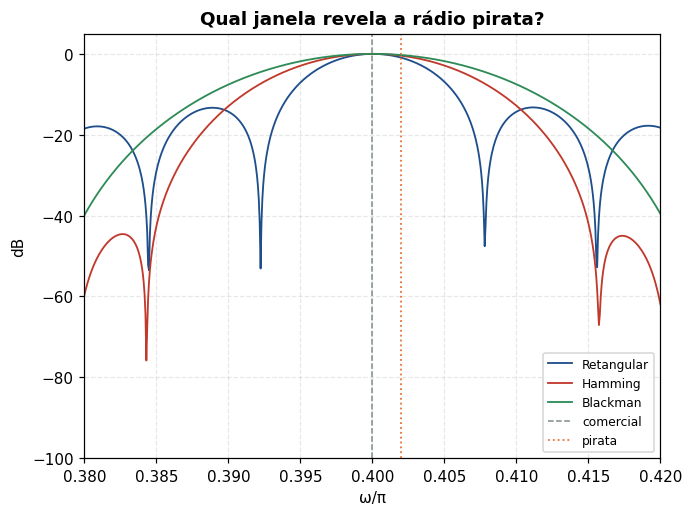

Dica: aumente L e dB_pirata e veja quando cada janela consegue (ou não) separar/revelar a pirata.


In [11]:
# --- Esqueleto do exercício: complete/ajuste e justifique sua escolha ---
L = 256                       # comprimento da janela (resolução)
fs = 1.0                      # frequência normalizada
f_comercial = 0.2000          # estação forte
f_pirata    = 0.2010          # estação pirata (próxima)
dB_pirata   = -35             # quão fraca é a pirata

n = np.arange(L)
x = np.cos(2*np.pi*f_comercial*n) + 10**(dB_pirata/20)*np.cos(2*np.pi*f_pirata*n)

plt.figure(figsize=(11, 4))
for nome, cor in [('Retangular', PALETA['azul']),
                  ('Hamming',    PALETA['vermelho']),
                  ('Blackman',   PALETA['verde'])]:
    w = signal.get_window(JANELAS[nome], L)
    ww, V = dtft(x*w, num=16384, faixa=(0, np.pi))
    Vdb = 20*np.log10(np.abs(V)/np.abs(V).max() + 1e-12)
    plt.plot(ww/np.pi, Vdb, lw=1.2, color=cor, label=nome)
plt.axvline(2*f_comercial, color=PALETA['cinza'], ls='--', lw=1, label='comercial')
plt.axvline(2*f_pirata,    color=PALETA['laranja'], ls=':', lw=1.2, label='pirata')
plt.xlim(0.38, 0.42); plt.ylim(-100, 5)
plt.xlabel('ω/π'); plt.ylabel('dB'); plt.legend(fontsize=8)
plt.title('Qual janela revela a rádio pirata?')
plt.tight_layout(); plt.show()

print('Dica: aumente L e dB_pirata e veja quando cada janela consegue (ou não) separar/revelar a pirata.')

<details>
<summary><b>► Solução comentada (clique para abrir)</b></summary>

<br>

O problema junta os **dois** compromissos, que apontam para janelas diferentes — então a resposta exige raciocínio, não uma escolha automática.

**Passo 1 — a resolução vem de $L$, não da janela.** As estações estão a $\Delta f = 0{,}1$ MHz. No caso normalizado ($f_c=0{,}2000$, $f_p=0{,}2010$) a separação em frequência angular é $\Delta(\omega/\pi)=2\,\Delta f = 0{,}002$. Para a janela retangular, o lobo principal (pico→1º nulo) tem meia-largura $2\pi/L$, ou seja $2/L$ em $\omega/\pi$. Só dá para **separar** as duas quando

$$ \frac{2}{L} \lesssim \Delta(\omega/\pi)=0{,}002 \;\Rightarrow\; L \gtrsim 1000. $$

Com o $L=256$ do esqueleto, $2/L = 0{,}0078 \gg 0{,}002$: as duas estações caem **dentro do mesmo lobo** e **nenhuma** janela resolve. *Primeiro é preciso aumentar $L$* (mais tempo de observação).

**Passo 2 — resolvido o $L$, a janela decide a faixa dinâmica.** Com $L \gtrsim 1000$ as duas se separam; agora o que decide se a **pirata fraca** aparece é o nível dos **lobos laterais**:
* **Retangular** ($-13$ dB): lobo estreito (ótima resolução), mas os lobos laterais altos **enterram** uma pirata mais de ~13 dB abaixo da comercial.
* **Blackman** ($-57$ dB): revela a pirata mesmo muito fraca, mas o lobo principal é ~3× mais largo (pior resolução) — exige $L$ ainda maior para separar.
* **Hamming** ($-41$ dB): **compromisso** — faixa dinâmica suficiente para a maioria dos casos, com lobo principal bem mais estreito que a Blackman.

**Resposta.** A escolha **depende do que limita o caso**:
- se a pirata é **moderadamente** fraca (até ~−40 dB) → **Hamming** é a melhor escolha (vê a pirata e ainda separa bem);
- se a pirata é **extremamente** fraca → **Blackman** (única com faixa dinâmica suficiente), aceitando aumentar $L$ para compensar a perda de resolução;
- a **Retangular** só venceria se a pirata fosse **forte** e o problema fosse *apenas* de separação.

Para o cenário típico do enunciado (pirata fraca e próxima), a justificativa esperada é **Hamming**, desde que $L$ seja grande o bastante para resolver — caso contrário, *nenhuma* janela funciona. A célula abaixo confirma os dois regimes.

</details>


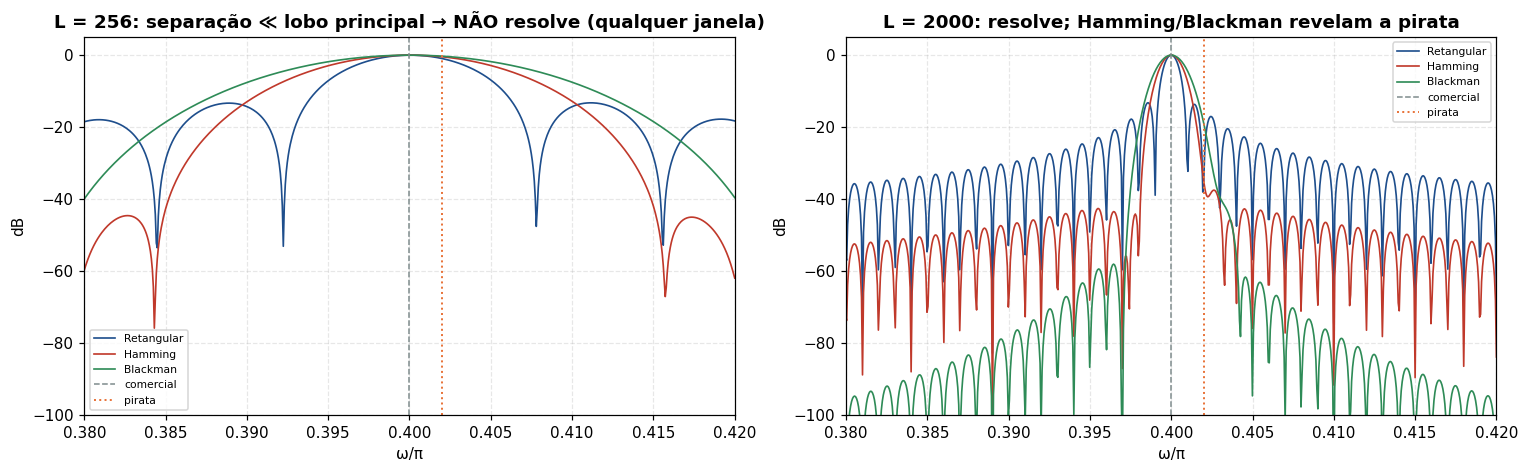

Separação entre estações: Δ(ω/π) = 0.0020
  L=  256:  meia-largura do lobo (retangular) = 0.0078  ->  não resolve
  L= 1000:  meia-largura do lobo (retangular) = 0.0020  ->  RESOLVE
  L= 2000:  meia-largura do lobo (retangular) = 0.0010  ->  RESOLVE


In [12]:
# === Solução do exercício: comparação nos dois regimes de L ===
def solucao_pirata(L, dB_pirata, fc=0.2000, fp=0.2010, ax=None):
    n = np.arange(L)
    x = np.cos(2*np.pi*fc*n) + 10**(dB_pirata/20)*np.cos(2*np.pi*fp*n)
    for nome, cor in [('Retangular', PALETA['azul']),
                      ('Hamming',    PALETA['vermelho']),
                      ('Blackman',   PALETA['verde'])]:
        w = signal.get_window(JANELAS[nome], L)
        ww, V = dtft(x*w, num=16384, faixa=(0, np.pi))
        Vdb = 20*np.log10(np.abs(V)/np.abs(V).max() + 1e-12)
        ax.plot(ww/np.pi, Vdb, lw=1.1, color=cor, label=nome)
    ax.axvline(2*fc, color=PALETA['cinza'],  ls='--', lw=1,   label='comercial')
    ax.axvline(2*fp, color=PALETA['laranja'], ls=':',  lw=1.3, label='pirata')
    ax.set_xlim(0.38, 0.42); ax.set_ylim(-100, 5)
    ax.set_xlabel('ω/π'); ax.set_ylabel('dB'); ax.legend(fontsize=7)

fig, (a, b) = plt.subplots(1, 2, figsize=(14, 4.4))
solucao_pirata(256,  -35, ax=a)   # como vem no esqueleto
a.set_title('L = 256: separação ≪ lobo principal → NÃO resolve (qualquer janela)')
solucao_pirata(2000, -35, ax=b)   # tempo de observação suficiente
b.set_title('L = 2000: resolve; Hamming/Blackman revelam a pirata')
plt.tight_layout(); plt.show()

# Critério quantitativo: separa quando meia-largura do lobo (2/L) <= separação
sep = 2*(0.2010 - 0.2000)          # separação em unidades de ω/π
print(f'Separação entre estações: Δ(ω/π) = {sep:.4f}')
for L in [256, 1000, 2000]:
    meia = 2/L
    print(f'  L={L:5d}:  meia-largura do lobo (retangular) = {meia:.4f}  ->  '
          + ('RESOLVE' if meia <= sep else 'não resolve'))


# Referências e laboratórios recomendados

**Base teórica desta aula**
- A. V. Oppenheim, R. W. Schafer. *Processamento em Tempo Discreto de Sinais*. 3ª ed., Pearson, 2013 (cadeia de processamento, exemplos de janelamento, janela de Kaiser).
- F. J. Harris. *On the use of windows for harmonic analysis with the DFT*. Proc. IEEE, 1978 (tabela de propriedades das janelas).
- R. G. Lyons. *Understanding Digital Signal Processing* (scalloping loss / picket-fence).

**Laboratórios interativos (pesquisa na internet)**
- **Brian McFee — *Digital Signals Theory*** — cap. 6 "Spectral leakage and windowing" (livro on-line interativo em Jupyter). `brianmcfee.net/dstbook-site`
- **J. Unpingco — *Python for Signal Processing*** — notebooks `Windowing_Part1/2.ipynb`. `github.com/unpingco/Python-for-Signal-Processing`
- **DSPIllustrations** — *Spectral Leakage, Zero-Padding and Frequency Resolution*. `dspillustrations.com`
- **Zurich Instruments — LabOne** — *How to control spectral leakage with window functions* (compromisso resolução × faixa dinâmica).
- Roteiros universitários: **UFlorida EEL3135** (spectral leakage), **Newcastle EEE305** (FFT, leakage, zero padding), **ECE 421 — Spectrum Analysis** (picket-fence e zero-padding).

<div style="background:#E8F0FE;border-left:6px solid #1E4E8C;padding:10px 14px;border-radius:4px;margin-top:10px">
<b>Resumo dos três efeitos:</b> (a) o <b>janelamento</b> alarga os picos e gera vazamento; (b) a <b>escolha da janela</b> troca resolução por faixa dinâmica; (c) a <b>amostragem espectral</b> (DFT amostra a DTFT) causa <i>picket-fence/scalloping</i>, atenuado — mas não resolvido — por <i>zero-padding</i>.
</div>
